# Hit Song Prediction Pipeline — Unified Notebook
---
**Sections:**
1. **GHW3 — Data Cleaning & Feature Engineering** (Tasks T1–T9)
2. **GHW4 — Baseline Modelling, Diagnostics & Precision-Recall** (Random Forest, Decision Tree, 3-Class Model)
3. **GHW5 — Failure Mode Analysis** (Error patterns, cost analysis, bias checks)

> Each section builds on the dataframe produced by the previous one.  
> Duplicate imports and repeated code blocks across the original notebooks have been removed.

---
# Part 1 — Data Cleaning & Feature Engineering (GHW3)

## T1 — Load CSVs & Remove Blanks
Load `songs.csv` and `artists.csv`, audit blank values, and replace them with `"Unknown"`.

In [3]:
import pandas as pd
import numpy as np
import ast

# ── Load raw CSVs ──────────────────────────────────────────────
dfsongs_org = pd.read_csv("/content/songs.csv", sep=',')
dfartists_org = pd.read_csv("/content/artists.csv", sep=',')

# ── Audit blanks in songs.csv ─────────────────────────────────
blank_counts_songs = (dfsongs_org.isna() | (dfsongs_org == "")).sum()
songs_table = pd.DataFrame(blank_counts_songs, columns=["blank_count"])
print("Blank Counts – Songs CSV")
display(songs_table)

# ── Replace blanks in songs.csv ───────────────────────────────
dfsongs_no_blanks = dfsongs_org.copy()
dfsongs_no_blanks["name"] = dfsongs_no_blanks["name"].replace("", "Unknown").fillna("Unknown")
dfsongs_no_blanks["album_name"] = dfsongs_no_blanks["album_name"].replace("", "Unknown").fillna("Unknown")

print("Created dfsongs_no_blanks — shape:", dfsongs_no_blanks.shape)
print("Blanks remaining:")
print((dfsongs_no_blanks.isna() | (dfsongs_no_blanks == "")).sum())

# ── Audit blanks in artists.csv ───────────────────────────────
blank_counts_artists = (dfartists_org.isna() | (dfartists_org == "")).sum()
artists_table = pd.DataFrame(blank_counts_artists, columns=["blank_count"])
print("\nBlank Counts – Artists CSV")
display(artists_table)

# ── Replace blanks in artists.csv ─────────────────────────────
dfartists_no_blanks = dfartists_org.copy()
dfartists_no_blanks["name"] = dfartists_no_blanks["name"].replace("", "Unknown").fillna("Unknown")
if "genre" in dfartists_no_blanks.columns:
    dfartists_no_blanks["genre"] = dfartists_no_blanks["genre"].replace("", "Unknown").fillna("Unknown")

print("Created dfartists_no_blanks — shape:", dfartists_no_blanks.shape)
print("Blanks remaining:")
print((dfartists_no_blanks.isna() | (dfartists_no_blanks == "")).sum())

Blank Counts – Songs CSV


,blank_count
id,0
name,3
album_name,20
artists,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0


Created dfsongs_no_blanks — shape: (550622, 24)
Blanks remaining:
id                        0
name                      0
album_name                0
artists                   0
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
valence                   0
tempo                     0
duration_ms               0
lyrics                    0
year                      0
genre                     0
popularity                0
total_artist_followers    0
avg_artist_popularity     0
artist_ids                0
niche_genres              0
dtype: int64

Blank Counts – Artists CSV


,blank_count
id,0
name,2
followers,0
popularity,0
genres,0
main_genre,0


Created dfartists_no_blanks — shape: (71440, 6)
Blanks remaining:
id            0
name          0
followers     0
popularity    0
genres        0
main_genre    0
dtype: int64


## T2 — Remove Duplicates
Identify and drop duplicate rows in both datasets.

In [4]:
# ═══════════════════════════════════════════════════════════════
# Songs — duplicates based on (name, artists, album_name)
# ═══════════════════════════════════════════════════════════════

dup_count = dfsongs_no_blanks.duplicated(subset=["name", "artists", "album_name"]).sum()
print("Duplicate song rows (same name + artist + album):", dup_count)

# Show a sample of duplicates before removal
dup_rows = dfsongs_no_blanks[
    dfsongs_no_blanks.duplicated(subset=["name", "artists", "album_name"], keep=False)
]
print("Preview of first 20 duplicate rows:")
display(dup_rows.head(20))

# Mark ALL members of each duplicate group, then remove them all
dupe_mask = dfsongs_no_blanks.duplicated(
    subset=["name", "artists", "album_name"], keep=False
)
print("Total rows flagged for removal:", dupe_mask.sum())

dfsongs_nodup = dfsongs_no_blanks[~dupe_mask].copy()
print("Shape after de-dup:", dfsongs_nodup.shape)
print("Remaining duplicates:", dfsongs_nodup.duplicated().sum())

# ═══════════════════════════════════════════════════════════════
# Artists — duplicates based on name only
# ═══════════════════════════════════════════════════════════════

dup_artist_count = dfartists_no_blanks.duplicated(subset=["name"]).sum()
print("\nDuplicate artist rows (same name):", dup_artist_count)

dup_artist_rows = dfartists_no_blanks[
    dfartists_no_blanks.duplicated(subset=["name"], keep=False)
].sort_values("name")
display(dup_artist_rows.head(10))

# Keep the first occurrence of each artist name
dfartists_nodup = dfartists_no_blanks.drop_duplicates(subset=["name"], keep="first").copy()
print("Artists shape after de-dup:", dfartists_nodup.shape)

Duplicate song rows (same name + artist + album): 18854
Preview of first 20 duplicate rows:


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
21,1hH0t381PIXmUVWyG1Vj3p,"""A"" You're Adorable",The Bashful Blond,"[""Brian Hyland""]",0.615,0.375,0,-10.362,0,0.0319,...,110.720,151680,A You're adorable\nB You're so beautiful\nC Yo...,1961,Pop,29,67223,47.0,"[""6YROFUbu5zRCHi2xkir5pk""]",[]
22,6CvreUbryAmXAUo35wuCQJ,"""A"" You're Adorable",The Bashful Blond,"[""Brian Hyland""]",0.615,0.375,0,-10.362,0,0.0319,...,110.720,151680,A You're adorable\nB You're so beautiful\nC Yo...,1961,Pop,0,67223,47.0,"[""6YROFUbu5zRCHi2xkir5pk""]",[]
50,14Klge4yTyUeFEn9yvBUjh,"""Eternal""",E. 1999 Eternal,"[""Bone Thugs-N-Harmony""]",0.818,0.513,1,-9.265,0,0.1880,...,80.047,243920,Where you from nigga?\n\nStraight from the mut...,1995,Hip-Hop,51,3329701,67.0,"[""5spEJXLwD1sKUdC2bnOHPg""]","[""g-funk"", ""gangster rap"", ""old school hip hop""]"
51,69mgGJKQwcebp7V0BAFGqy,"""Eternal""",E. 1999 Eternal,"[""Bone Thugs-N-Harmony""]",0.800,0.349,1,-15.003,0,0.3460,...,80.050,256320,Where you from nigga?\n[Layzie Bone]\nStraight...,1995,Hip-Hop,24,3329701,67.0,"[""5spEJXLwD1sKUdC2bnOHPg""]","[""g-funk"", ""gangster rap"", ""old school hip hop""]"
52,0rcZOxi2vzeERpiKIYBork,"""Farewell"" Symphony",Future Teenage Cave Artists,"[""Deerhoof""]",0.619,0.816,1,-6.843,1,0.0769,...,124.124,229895,Inner opera continue forever\nPeople who came ...,2020,Rock,0,123108,21.0,"[""7AZwAitWq1KcFoIJhRWb6V""]","[""noise rock""]"
53,6pZJjbL6q3cdlp5dHDlLLM,"""Farewell"" Symphony",Future Teenage Cave Artists,"[""Deerhoof""]",0.630,0.840,1,-6.829,1,0.0751,...,124.121,229895,Inner opera continue forever\nPeople who came ...,2020,Rock,0,123108,21.0,"[""7AZwAitWq1KcFoIJhRWb6V""]","[""noise rock""]"
101,1ReFo3JhwYbk1XOlOQu3ka,"""Ole"" Baugh Road",Southern Star,"[""Alabama""]",0.693,0.646,7,-9.826,1,0.0280,...,124.251,231267,"'Round Ole Baugh Road, it's a great place for ...",1989,Country,0,1682413,67.0,"[""6rJqqRce0Kvo2dJUXoHleC""]","[""classic country"", ""country"", ""country christ..."
102,1ScOKADKsoLy6RXGvDl18S,"""Ole"" Baugh Road",Southern Star,"[""Alabama""]",0.693,0.646,7,-9.826,1,0.0280,...,124.251,231267,"'Round Ole Baugh Road, it's a great place for ...",1989,Country,17,1682413,67.0,"[""6rJqqRce0Kvo2dJUXoHleC""]","[""classic country"", ""country"", ""country christ..."
126,3rG8ZkmKHb4Ms6CsSzEITv,"""The Take Over, The Breaks Over""",Infinity On High,"[""Fall Out Boy""]",0.609,0.917,9,-2.563,1,0.0477,...,149.948,213587,"Baby, seasons change but people don't\nAnd I'l...",2007,Rock,65,11518757,81.0,"[""4UXqAaa6dQYAk18Lv7PEgX""]","[""emo"", ""pop punk""]"
127,4zCfMDdf5QXPKEqxdinXvB,"""The Take Over, The Breaks Over""",Infinity On High,"[""Fall Out Boy""]",0.608,0.916,9,-2.562,1,0.0473,...,149.957,213587,"Baby, seasons change but people don't\nAnd I'l...",2007,Rock,37,11518757,81.0,"[""4UXqAaa6dQYAk18Lv7PEgX""]","[""emo"", ""pop punk""]"


Total rows flagged for removal: 36685
Shape after de-dup: (513937, 24)
Remaining duplicates: 0

Duplicate artist rows (same name): 1796


,id,name,followers,popularity,genres,main_genre
68100,3T6ivAHTFCD5r5S8xeaP2J,100%,15444,29,"['lo-fi indie', 'slowcore']",Electronic
62026,3fkFO5lmipe654caBLBD6n,100%,169188,24,['k-pop'],Pop
52272,2lTBSDLVs28fnS9dfX5XnZ,12th Planet,437,27,['dubstep'],Electronic
25917,3V1h3kAdiVDBiwlY2i6dJz,12th Planet,186024,36,"['dubstep', 'riddim', 'deathstep', 'dub', 'bas...",Electronic
11805,5gPZ9xZ09FdYzbHIdGB2bA,1st Klase,1815,15,['dancehall'],Folk
11668,0Pv1Rvzc107NT2WDrEMtsF,1st Klase,25,3,[],Folk
51919,1jluLAiBpHzUX4DlOxOfU3,2Face,7974,25,['aussie drill'],Hip-Hop
65752,0bX7oyjN0NWlnirtTd6CDe,2Face,1823,28,['azonto'],Hip-Hop
57589,1lK8Se716uGGB5NB2F2V9S,3,28,0,[],Rock
31530,1BYnP5HY7Ci0MFEHiDV1Ww,3,15911,23,"['progressive metal', 'progressive rock']",Rock


Artists shape after de-dup: (69644, 6)


## T3 — Lyric Word Count, Niche-Genre Count & Column Pruning
Create `lyric_word_count` and `niche_genre_count`, then drop columns that are
unique identifiers or would cause time-travel leakage (`lyrics`, `artist_ids`,
`niche_genres`, `total_artist_followers`).

In [5]:
dfsongs_final = dfsongs_nodup.copy()

# 1. Word count from lyrics
dfsongs_final["lyric_word_count"] = (
    dfsongs_final["lyrics"].fillna("").apply(lambda x: len(x.split()))
)

# 2. Parse niche_genres string → Python list
dfsongs_final["niche_genres_list"] = (
    dfsongs_final["niche_genres"]
    .apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
)

# 3. Count niche sub-genres per track
dfsongs_final["niche_genre_count"] = (
    dfsongs_final["niche_genres_list"]
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
)

# 4. Drop columns no longer needed
dfsongs_final = dfsongs_final.drop(
    columns=["lyrics", "artist_ids", "niche_genres", "niche_genres_list",
             "total_artist_followers"],
    errors="ignore"
)

display(dfsongs_final.head(10))

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,duration_ms,year,genre,popularity,avg_artist_popularity,lyric_word_count,niche_genre_count
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,0.4710,0.193,100.059,79500,2016,Rock,0,52.0,428,2
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,0.1760,0.287,79.998,114000,2019,Hip-Hop,29,45.0,217,0
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,0.3300,0.349,175.317,197400,2002,Rock,0,35.0,210,4
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,0.1090,0.688,142.959,178533,2018,Hip-Hop,43,63.0,556,1
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,0.1310,0.380,86.103,186197,2018,Hip-Hop,0,63.0,359,1
5,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,Da Capo (Deluxe Edition),"[""Love""]",0.600,0.540,9,-11.803,1,0.0328,...,0.1000,0.547,125.898,220560,1966,Rock,20,46.0,123,4
6,1SCFa6gt3r6juLsIqpdwY3,!liaF cipE,The Bree-TeenZ,"[""One Morning Left""]",0.483,0.894,9,-4.164,1,0.0546,...,0.3740,0.284,140.058,200200,2011,Rock,0,34.0,260,2
7,1JrpMwlzPuWgfmGiIBi9QI,""" """,Burner,"[""Breadwinner""]",0.296,0.831,4,-8.101,1,0.0415,...,0.0824,0.217,124.921,201760,1994,Rock,0,16.0,35,4
8,5PIf0fmKJzgK8jgyqXaHGZ,""" R.I.P """,Escape,"[""Ram-Zet""]",0.474,0.923,6,-4.611,1,0.1480,...,0.1870,0.288,159.974,533160,2002,Rock,0,7.0,246,4
9,0sZb4GBh64F0FOZzQy6QqV,"""...Because All Suffering Is Sweet to Me...""",Lucy Gray,"[""Envy On The Coast""]",0.241,0.734,4,-6.919,0,0.0671,...,0.1100,0.040,157.355,237973,2007,Rock,23,31.0,254,1


## T4 — One-Hot Encode Genres
Convert the categorical `genre` column into binary indicator columns.

In [6]:
dfsongs_encoded = dfsongs_final.copy()

genre_dummies = pd.get_dummies(dfsongs_encoded["genre"], prefix="genre", dtype=int)
dfsongs_encoded = pd.concat([dfsongs_encoded, genre_dummies], axis=1)

print("Shape after one-hot encoding:", dfsongs_encoded.shape)
display(dfsongs_encoded.head(10))

Shape after one-hot encoding: (513937, 32)


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,genre_Blues,genre_Classical,genre_Country,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Jazz,genre_Pop,genre_R&B,genre_Rock
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,0,0,0,0,0,0,0,0,0,1
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,0,0,0,0,0,1,0,0,0,0
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,0,0,0,0,0,0,0,0,0,1
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,0,0,0,0,0,1,0,0,0,0
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,0,0,0,0,0,1,0,0,0,0
5,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,Da Capo (Deluxe Edition),"[""Love""]",0.600,0.540,9,-11.803,1,0.0328,...,0,0,0,0,0,0,0,0,0,1
6,1SCFa6gt3r6juLsIqpdwY3,!liaF cipE,The Bree-TeenZ,"[""One Morning Left""]",0.483,0.894,9,-4.164,1,0.0546,...,0,0,0,0,0,0,0,0,0,1
7,1JrpMwlzPuWgfmGiIBi9QI,""" """,Burner,"[""Breadwinner""]",0.296,0.831,4,-8.101,1,0.0415,...,0,0,0,0,0,0,0,0,0,1
8,5PIf0fmKJzgK8jgyqXaHGZ,""" R.I.P """,Escape,"[""Ram-Zet""]",0.474,0.923,6,-4.611,1,0.1480,...,0,0,0,0,0,0,0,0,0,1
9,0sZb4GBh64F0FOZzQy6QqV,"""...Because All Suffering Is Sweet to Me...""",Lucy Gray,"[""Envy On The Coast""]",0.241,0.734,4,-6.919,0,0.0671,...,0,0,0,0,0,0,0,0,0,1


## T5 — Tempo Deviation Feature
Compute each track's deviation from its genre's median tempo.

In [7]:
dfsongs_features = dfsongs_encoded.copy()

# Median tempo by genre
median_tempo = dfsongs_features.groupby("genre")["tempo"].median()
dfsongs_features["tempo_deviation_bpm"] = (
    dfsongs_features["tempo"] - dfsongs_features["genre"].map(median_tempo)
)

print("Sample with tempo_deviation_bpm:")
display(dfsongs_features.head(10))

# Summary table: median tempo & count per genre
genre_counts = dfsongs_features.groupby("genre")["tempo"].count().rename("count")
genre_tempo_averages = (
    median_tempo.reset_index().rename(columns={"tempo": "median_tempo_bpm"})
    .merge(genre_counts.reset_index(), on="genre")
    .sort_values("median_tempo_bpm", ascending=False)
    .reset_index(drop=True)
)
print("\nMedian tempo by genre:")
print(genre_tempo_averages)

Sample with tempo_deviation_bpm:


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,genre_Classical,genre_Country,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Jazz,genre_Pop,genre_R&B,genre_Rock,tempo_deviation_bpm
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,0,0,0,0,0,0,0,0,1,-24.717
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,0,0,0,0,1,0,0,0,0,-28.548
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,0,0,0,0,0,0,0,0,1,50.541
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,0,0,0,0,1,0,0,0,0,34.413
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,0,0,0,0,1,0,0,0,0,-22.443
5,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,Da Capo (Deluxe Edition),"[""Love""]",0.600,0.540,9,-11.803,1,0.0328,...,0,0,0,0,0,0,0,0,1,1.122
6,1SCFa6gt3r6juLsIqpdwY3,!liaF cipE,The Bree-TeenZ,"[""One Morning Left""]",0.483,0.894,9,-4.164,1,0.0546,...,0,0,0,0,0,0,0,0,1,15.282
7,1JrpMwlzPuWgfmGiIBi9QI,""" """,Burner,"[""Breadwinner""]",0.296,0.831,4,-8.101,1,0.0415,...,0,0,0,0,0,0,0,0,1,0.145
8,5PIf0fmKJzgK8jgyqXaHGZ,""" R.I.P """,Escape,"[""Ram-Zet""]",0.474,0.923,6,-4.611,1,0.1480,...,0,0,0,0,0,0,0,0,1,35.198
9,0sZb4GBh64F0FOZzQy6QqV,"""...Because All Suffering Is Sweet to Me...""",Lucy Gray,"[""Envy On The Coast""]",0.241,0.734,4,-6.919,0,0.0671,...,0,0,0,0,0,0,0,0,1,32.579



Median tempo by genre:
        genre  median_tempo_bpm   count
0  Electronic          126.9820   64849
1        Rock          124.7760  186583
2         Pop          120.3070   66823
3     Country          119.2570   43859
4        Folk          117.0180   46911
5       Blues          115.6920   15031
6   Classical          113.9750   11529
7         R&B          111.6545   25062
8        Jazz          110.6710   16285
9     Hip-Hop          108.5460   37005


## T6 — Mood × Energy Interaction
Multiply `valence` by `energy` (both already 0–1) to capture upbeat sentiment.

In [8]:
dfsongs_features_mood = dfsongs_features.copy()

dfsongs_features_mood["mood_energy_interaction"] = (
    dfsongs_features_mood["valence"] * dfsongs_features_mood["energy"]
)

print("Sample with mood_energy_interaction:")
display(dfsongs_features_mood.head(10))

Sample with mood_energy_interaction:


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,genre_Country,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Jazz,genre_Pop,genre_R&B,genre_Rock,tempo_deviation_bpm,mood_energy_interaction
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,0,0,0,0,0,0,0,1,-24.717,0.116765
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,0,0,0,1,0,0,0,0,-28.548,0.185976
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,0,0,0,0,0,0,0,1,50.541,0.333993
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,0,0,0,1,0,0,0,0,34.413,0.421056
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,0,0,0,1,0,0,0,0,-22.443,0.209760
5,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,Da Capo (Deluxe Edition),"[""Love""]",0.600,0.540,9,-11.803,1,0.0328,...,0,0,0,0,0,0,0,1,1.122,0.295380
6,1SCFa6gt3r6juLsIqpdwY3,!liaF cipE,The Bree-TeenZ,"[""One Morning Left""]",0.483,0.894,9,-4.164,1,0.0546,...,0,0,0,0,0,0,0,1,15.282,0.253896
7,1JrpMwlzPuWgfmGiIBi9QI,""" """,Burner,"[""Breadwinner""]",0.296,0.831,4,-8.101,1,0.0415,...,0,0,0,0,0,0,0,1,0.145,0.180327
8,5PIf0fmKJzgK8jgyqXaHGZ,""" R.I.P """,Escape,"[""Ram-Zet""]",0.474,0.923,6,-4.611,1,0.1480,...,0,0,0,0,0,0,0,1,35.198,0.265824
9,0sZb4GBh64F0FOZzQy6QqV,"""...Because All Suffering Is Sweet to Me...""",Lucy Gray,"[""Envy On The Coast""]",0.241,0.734,4,-6.919,0,0.0671,...,0,0,0,0,0,0,0,1,32.579,0.029360


## T7 — Popularity Ordinal Encoding (Target Variable)
Use percentile analysis to bin `popularity` into four tiers:

| Tier | Popularity Range | Label |
|------|-----------------|-------|
| 0 | 0–10 | Unpopular |
| 1 | 11–30 | Moderate |
| 2 | 31–49 | Strong |
| 3 | 50+ (≥ 95th pctl) | Hit |

In [9]:
import matplotlib.pyplot as plt

# Verify the 95th percentile
hit_threshold = dfsongs_features_mood["popularity"].quantile(0.95)
print("95th percentile popularity threshold:", hit_threshold)
num_hits = (dfsongs_features_mood["popularity"] >= hit_threshold).sum()
print("Songs at or above 95th percentile:", num_hits)

# ── Ordinal encoder ───────────────────────────────────────────
def encode_popularity(pop):
    if pop <= 10:
        return 0   # Unpopular
    elif pop <= 30:
        return 1   # Moderate
    elif pop < 50:
        return 2   # Strong
    else:
        return 3   # Hit (≥ 95th percentile)

dfsongs_ordinal = dfsongs_features_mood.copy()
dfsongs_ordinal["popularity_tier"] = dfsongs_ordinal["popularity"].apply(encode_popularity)

print(dfsongs_ordinal[["popularity", "popularity_tier"]].head(20))

95th percentile popularity threshold: 50.0
Songs at or above 95th percentile: 26113
    popularity  popularity_tier
0            0                0
1           29                1
2            0                0
3           43                2
4            0                0
5           20                1
6            0                0
7            0                0
8            0                0
9           23                1
10           0                0
11          34                2
12          38                2
13          36                2
14          29                1
15          33                2
16          50                3
17          46                2
18          19                1
19          35                2


## T8 — Party Score
`energy × danceability` — captures how upbeat and dance-friendly a track is.

In [10]:
dfsongs_party = dfsongs_ordinal.copy()

dfsongs_party["party_score"] = (
    dfsongs_party["energy"] * dfsongs_party["danceability"]
)

print(dfsongs_party[["energy", "danceability", "party_score"]].head(20))

    energy  danceability  party_score
0    0.605         0.415     0.251075
1    0.648         0.788     0.510624
2    0.957         0.171     0.163647
3    0.612         0.823     0.503676
4    0.552         0.729     0.402408
5    0.540         0.600     0.324000
6    0.894         0.483     0.431802
7    0.831         0.296     0.245976
8    0.923         0.474     0.437502
9    0.734         0.241     0.176894
10   0.480         0.368     0.176640
11   0.684         0.272     0.186048
12   0.545         0.371     0.202195
13   0.545         0.371     0.202195
14   0.196         0.457     0.089572
15   0.563         0.968     0.544984
16   0.970         0.315     0.305550
17   0.804         0.552     0.443808
18   0.156         0.683     0.106548
19   0.503         0.428     0.215284


## T9 — Song / Album Name Significance (OLS Regression)
Add `name_char_count` and `album_char_count`, run OLS to test whether they
are statistically significant predictors of popularity, then drop non-numeric
identifier columns.

In [11]:
import statsmodels.api as sm

dfsongs_party_copy = dfsongs_party.copy()

# ── Character-length features ─────────────────────────────────
dfsongs_party_copy["name_char_count"] = dfsongs_party_copy["name"].astype(str).str.len()
dfsongs_party_copy["album_char_count"] = dfsongs_party_copy["album_name"].astype(str).str.len()

# ── OLS regression (all numeric predictors vs. popularity) ────
numeric_cols = dfsongs_party_copy.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop(["popularity", "popularity_tier"])
numeric_cols = [c for c in numeric_cols if not c.startswith("genre_")]

y = dfsongs_party_copy["popularity"]
X = sm.add_constant(dfsongs_party_copy[numeric_cols])
model = sm.OLS(y, X).fit()
print(model.summary())

# ── Drop text identifiers & rename targets ────────────────────
dfsongs_party_copy = dfsongs_party_copy.drop(columns=["name", "album_name", "artists"])
dfsongs_party_copy = dfsongs_party_copy.rename(columns={
    "popularity": "popularity_target",
    "popularity_tier": "target_popularity_tier"
}).drop(columns=["genre"])

display(dfsongs_party_copy.head(10))

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     5923.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:50:54   Log-Likelihood:            -2.1318e+06
No. Observations:              513937   AIC:                         4.264e+06
Df Residuals:                  513915   BIC:                         4.264e+06
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

,id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,genre_Jazz,genre_Pop,genre_R&B,genre_Rock,tempo_deviation_bpm,mood_energy_interaction,target_popularity_tier,party_score,name_char_count,album_char_count
0,0Prct5TDjAnEgIqbxcldY9,0.415,0.605,7,-11.157,1,0.0575,0.001160,0.838000,0.4710,...,0,0,0,1,-24.717,0.116765,0,0.251075,1,10
1,2ASl4wirkeYm3OWZxXKYuq,0.788,0.648,7,-9.135,0,0.3150,0.900000,0.000000,0.1760,...,0,0,0,0,-28.548,0.185976,1,0.510624,2,16
2,5tA3ImW310llKo8EMBj2Ga,0.171,0.957,2,-5.749,1,0.1490,0.000029,0.000032,0.3300,...,0,0,0,1,50.541,0.333993,0,0.163647,19,19
3,0fROT4kK5oTm8xO8PX6EJF,0.823,0.612,1,-7.767,1,0.2480,0.168000,0.000000,0.1090,...,0,0,0,0,34.413,0.421056,2,0.503676,14,14
4,1xBFhv5faebv3mmwxx7DnS,0.729,0.552,7,-8.562,0,0.0650,0.183000,0.000000,0.1310,...,0,0,0,0,-22.443,0.209760,0,0.402408,6,6
5,0gNNToCW3qjabgTyBSjt3H,0.600,0.540,9,-11.803,1,0.0328,0.525000,0.003050,0.1000,...,0,0,0,1,1.122,0.295380,1,0.324000,25,24
6,1SCFa6gt3r6juLsIqpdwY3,0.483,0.894,9,-4.164,1,0.0546,0.000027,0.003940,0.3740,...,0,0,0,1,15.282,0.253896,0,0.431802,10,14
7,1JrpMwlzPuWgfmGiIBi9QI,0.296,0.831,4,-8.101,1,0.0415,0.000004,0.912000,0.0824,...,0,0,0,1,0.145,0.180327,0,0.245976,3,6
8,5PIf0fmKJzgK8jgyqXaHGZ,0.474,0.923,6,-4.611,1,0.1480,0.000596,0.477000,0.1870,...,0,0,0,1,35.198,0.265824,0,0.437502,9,6
9,0sZb4GBh64F0FOZzQy6QqV,0.241,0.734,4,-6.919,0,0.0671,0.020400,0.000000,0.1100,...,0,0,0,1,32.579,0.029360,1,0.176894,44,9


## Export — Save Final Cleaned Dataset

In [12]:
dfsongs_final = dfsongs_party_copy.copy()
dfsongs_final.to_csv("dfsongs_final.csv", index=False)
print("Saved dfsongs_final.csv — shape:", dfsongs_final.shape)
print(dfsongs_final.dtypes)

Saved dfsongs_final.csv — shape: (513937, 34)
id                          object
danceability               float64
energy                     float64
key                          int64
loudness                   float64
mode                         int64
speechiness                float64
acousticness               float64
instrumentalness           float64
liveness                   float64
valence                    float64
tempo                      float64
duration_ms                  int64
year                         int64
popularity_target            int64
avg_artist_popularity      float64
lyric_word_count             int64
niche_genre_count            int64
genre_Blues                  int64
genre_Classical              int64
genre_Country                int64
genre_Electronic             int64
genre_Folk                   int64
genre_Hip-Hop                int64
genre_Jazz                   int64
genre_Pop                    int64
genre_R&B                    int64
genre_Roc

---
# Part 2 — Baseline Modelling & Precision-Recall Analysis (GHW4)

## Load the Cleaned Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("/content/dfsongs_final.csv")
print("Loaded df — shape:", df.shape)
df.dtypes

Loaded df — shape: (513937, 34)


,0
id,object
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64
acousticness,float64
instrumentalness,float64
liveness,float64


## Baseline 4-Class Random Forest (with Leakage Checks)
Train a Random Forest on all numeric features to predict `target_popularity_tier`
(0, 1, 2, 3). Before training we verify there is no data leakage (columns identical
to or highly correlated with the target).

Dropped 'popularity_target'.
31 numeric features (first 10): ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']

--- Leakage checks ---
Columns identical to target: None
Features with |corr| > 0.95: None

Top 10 feature importances (quick diagnostic):
avg_artist_popularity    0.100940
lyric_word_count         0.052370
year                     0.052186
loudness                 0.050835
acousticness             0.049801
liveness                 0.049691
duration_ms              0.049256
speechiness              0.049028
danceability             0.047917
party_score              0.046496
dtype: float64

Train/test split OK — no overlapping indices.

Classification Report (test set):

              precision    recall  f1-score   support

           0     0.5974    0.7664    0.6714     44719
           1     0.4972    0.4663    0.4813     34232
           2     0.4215    0.2625    0.3235     18614
           3    

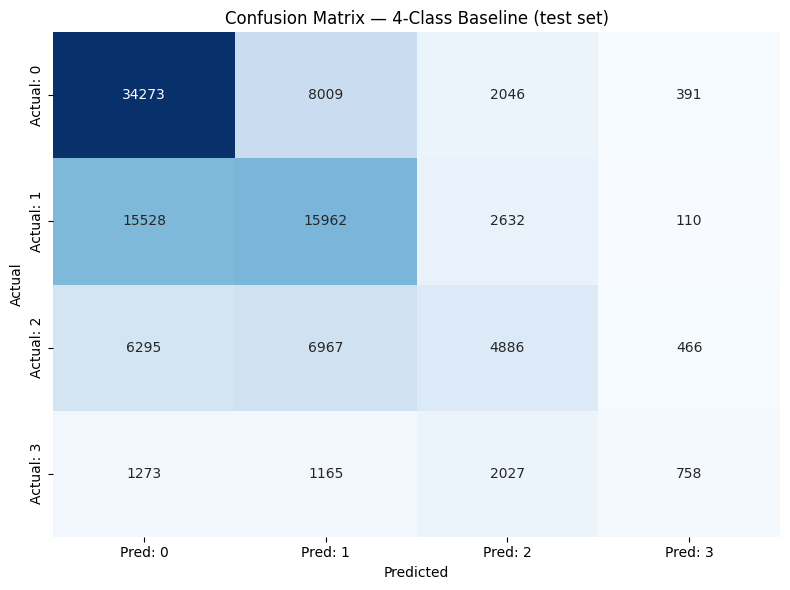

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ── Configuration ─────────────────────────────────────────────
target_col = "target_popularity_tier"
drop_col = "popularity_target"        # raw score would leak the ordinal target
rf_params = {"n_estimators": 200, "random_state": 42, "n_jobs": -1}
test_size = 0.2

# ── Drop leakage column ──────────────────────────────────────
if drop_col in df.columns:
    df = df.drop(columns=[drop_col])
    print(f"Dropped '{drop_col}'.")

# ── Validate target ───────────────────────────────────────────
y_all = df[target_col]
if not np.issubdtype(y_all.dtype, np.integer):
    df[target_col] = y_all.astype(int)

expected_classes = np.array([0, 1, 2, 3])

# ── Build feature list (numeric only) ────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]
print(f"{len(feature_cols)} numeric features (first 10): {feature_cols[:10]}")

# ── Leakage checks ───────────────────────────────────────────
print("\n--- Leakage checks ---")

# Columns identical to target
identical = [c for c in feature_cols
             if (df[c].fillna(-9999999) == df[target_col].fillna(-9999999)).all()]
print("Columns identical to target:", identical or "None")

# High absolute correlation with target (> 0.95)
corrs = df[feature_cols + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
high_corr = corrs[(corrs.index != target_col) & (corrs > 0.95)]
print("Features with |corr| > 0.95:", high_corr.to_dict() if not high_corr.empty else "None")

# Quick feature-importance dominance check
rf_quick = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
X_quick = df[feature_cols].sample(n=min(20000, len(df)), random_state=42)
y_quick = df.loc[X_quick.index, target_col]
rf_quick.fit(X_quick, y_quick)
imp_quick = pd.Series(rf_quick.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 feature importances (quick diagnostic):")
print(imp_quick.head(10))
if imp_quick.iloc[0] > 0.5:
    print(f"⚠ Single feature dominates (>50%): {imp_quick.index[0]} = {imp_quick.iloc[0]:.3f}")

# ── Train / test split ───────────────────────────────────────
X = df[feature_cols]
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, stratify=y, random_state=42
)
assert not set(X_train.index) & set(X_test.index), "Index overlap!"
print("\nTrain/test split OK — no overlapping indices.")

# ── Pipeline: StandardScaler → Random Forest ──────────────────
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(**rf_params))
])
pipe.fit(X_train, y_train)

# ── Evaluation ────────────────────────────────────────────────
y_pred = pipe.predict(X_test)
report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
print("\nClassification Report (test set):\n")
print(report_text)

# Confusion matrix
labels_sorted = expected_classes[np.isin(expected_classes,
    np.unique(np.concatenate([np.asarray(y_test), np.asarray(y_pred)])))]
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=[f"Pred: {int(n)}" for n in labels_sorted],
            yticklabels=[f"Actual: {int(n)}" for n in labels_sorted])
plt.title("Confusion Matrix — 4-Class Baseline (test set)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

## Decision Tree Visualisation
A full-depth Decision Tree is trained and visualised (capped at depth 6 for
readability) to inspect which features drive tier predictions.

### Decision tree — `target_popularity_tier` (display depth=6)

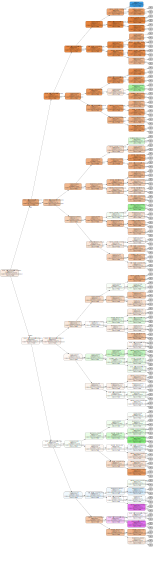

In [15]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz, io
from IPython.display import display, Markdown

# ── Config ────────────────────────────────────────────────────
plot_max_depth = 6

# ── Sanitise feature names for Graphviz (remove special chars) ─
def sanitize(name):
    return name.replace("&", "and").replace("<", "").replace(">", "").replace('"', "").replace("'", "")

safe_features = [sanitize(f) for f in feature_cols]
rename_map = dict(zip(feature_cols, safe_features))

X_dt = df[feature_cols].rename(columns=rename_map).fillna(-99999)
y_dt = df[target_col].astype(int)

# ── Train tree ────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_dt, y_dt)

# ── Export to Graphviz ────────────────────────────────────────
class_names = [f"Tier {int(c)}" for c in np.sort(y_dt.unique())]

dot_buf = io.StringIO()
export_graphviz(dt, out_file=dot_buf, feature_names=safe_features,
                class_names=class_names, filled=True, rounded=True,
                special_characters=True, max_depth=plot_max_depth, proportion=True)
dot_text = dot_buf.getvalue()

# Add left-to-right layout
idx = dot_text.find("{", dot_text.find("digraph"))
if idx != -1:
    dot_text = dot_text[:idx+1] + ' rankdir=LR; size="12,8"; node [shape=box]; ' + dot_text[idx+1:]

display(Markdown(f"### Decision tree — `{target_col}` (display depth={plot_max_depth})"))
display(graphviz.Source(dot_text, format="svg"))

## Precision–Recall Curve — Tier 3 (Hits)
A binary PR curve to understand the precision/recall trade-off when detecting
hit songs (tier 3) specifically.

<Figure size 800x600 with 0 Axes>

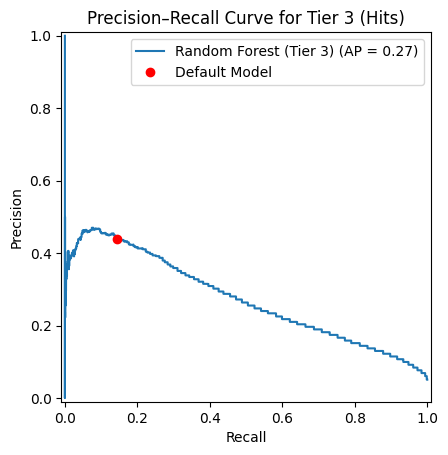

In [16]:
from sklearn.metrics import PrecisionRecallDisplay

# Binary labels: 1 = Hit (tier 3), 0 = everything else
y_test_binary = (y_test == 3).astype(int)
p_hit = pipe.predict_proba(X_test)[:, 3]

plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test_binary, p_hit,
                                         name="Random Forest (Tier 3)")
plt.title("Precision–Recall Curve for Tier 3 (Hits)")
plt.xlabel("Recall"); plt.ylabel("Precision")

# Mark the default-threshold operating point
default_recall = 0.145
default_precision = 0.439
plt.plot(default_recall, default_precision, 'ro', label='Default Model')
plt.legend(); plt.show()

## 3-Class Collapsed Model (Flop / Moderate / Hit)
Collapse the original four tiers into three classes to improve class balance
and train a balanced Random Forest with optional probability thresholding.

| New Class | Original Tiers | Label |
|-----------|---------------|-------|
| 0 | 0 | Flop |
| 1 | 1 + 2 | Moderate |
| 2 | 3 | Hit |

In [3]:
# ------------------------------------
### 3-Class Collapsed Model (Flop / Moderate / Hit) - Final tuning strategy
# -------------------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score,
    confusion_matrix, classification_report
)

# -------------------------------------------------------
# 1. Load and prepare data
# -------------------------------------------------------
target_col = "target_popularity_tier"
drop_col = "popularity_target"

df_original = df.copy()

# Drop leakage column if present
if drop_col in df_original.columns:
    df_original = df_original.drop(columns=[drop_col])

# Features and ORIGINAL target
X = df_original.select_dtypes(include=[np.number]).drop(columns=[target_col])
y_original = df_original[target_col].astype(int)

# -------------------------------------------------------
# 2. CREATE NEW 3-CLASS TARGET
# -------------------------------------------------------
# Mapping:
# Original 0 -> New 0 (Flop)
# Original 1 + 2 -> New 1 (Moderate)
# Original 3 -> New 2 (Hit)

def collapse_classes(y):
    y_new = np.where(y == 0, 0,           # Flop stays 0
                     np.where(y == 3, 2,  # Hit becomes 2
                              1))         # Everything else (1,2) becomes 1 (Moderate)
    return y_new

y_collapsed = collapse_classes(y_original)

print("=== CLASS DISTRIBUTION ===")
print("\nOriginal 4-class distribution:")
for i in range(4):
    count = (y_original == i).sum()
    pct = count / len(y_original) * 100
    print(f"  Class {i}: {count:6d} ({pct:5.2f}%)")

print("\nNew 3-class distribution:")
class_names = ['Flop', 'Moderate', 'Hit']
for i in range(3):
    count = (y_collapsed == i).sum()
    pct = count / len(y_collapsed) * 100
    print(f"  Class {i} ({class_names[i]:8s}): {count:6d} ({pct:5.2f}%)")

# -------------------------------------------------------
# 3. Train/test split with NEW target
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_collapsed, test_size=0.2, stratify=y_collapsed, random_state=42
)

# -------------------------------------------------------
# 4. Train Random Forest on 3 classes
# -------------------------------------------------------
pipe_3class = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("\n=== TRAINING 3-CLASS MODEL ===")
pipe_3class.fit(X_train, y_train)

# -------------------------------------------------------
# 5. Get predictions and probabilities
# -------------------------------------------------------
y_pred = pipe_3class.predict(X_test)
probs_all = pipe_3class.predict_proba(X_test)

# -------------------------------------------------------
# 6. BASELINE RESULTS (no thresholding)
# -------------------------------------------------------
print("\n" + "="*60)
print("BASELINE 3-CLASS MODEL (No Thresholding)")
print("="*60)
print(classification_report(y_test, y_pred,
                          target_names=class_names,
                          digits=4,
                          zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# -------------------------------------------------------
# 7. Class 2 (Hit) probability diagnostics
# -------------------------------------------------------
print("\n" + "="*60)
print("CLASS 2 (HIT SONGS) PROBABILITY DIAGNOSTICS")
print("="*60)
print(f"Max Class 2 probability: {probs_all[:, 2].max():.4f}")
print(f"Mean Class 2 probability: {probs_all[:, 2].mean():.4f}")
print(f"Median Class 2 probability: {np.median(probs_all[:, 2]):.4f}")

print(f"\nPercentiles of Class 2 probabilities:")
for p in [50, 75, 90, 95, 99, 100]:
    val = np.percentile(probs_all[:, 2], p)
    print(f"  {p}th percentile: {val:.4f}")

print(f"\nSamples with Class 2 prob >= 0.50: {(probs_all[:, 2] >= 0.50).sum()}")
print(f"Samples with Class 2 prob >= 0.70: {(probs_all[:, 2] >= 0.70).sum()}")
print(f"Samples with Class 2 prob >= 0.90: {(probs_all[:, 2] >= 0.90).sum()}")

print(f"\nActual Class 2 (Hit) samples in test set: {(y_test == 2).sum()}")

# -------------------------------------------------------
# 8. OPTIONAL: Apply thresholding if needed
# -------------------------------------------------------
# If you still want to boost Hit precision with thresholding:

threshold_flop = 0.75      # Class 0 (Flop)
threshold_moderate = 0.50   # Class 1 (Moderate)
threshold_hit = 0.5       # Class 2 (Hit)

y_pred_thresh = []

for prob_row in probs_all:
    # Priority: Check Hit class first
    if prob_row[2] >= threshold_hit:
        y_pred_thresh.append(2)
    elif prob_row[0] >= threshold_flop:
        y_pred_thresh.append(0)
    elif prob_row[1] >= threshold_moderate:
        y_pred_thresh.append(1)
    else:
        y_pred_thresh.append(np.argmax(prob_row))

y_pred_thresh = np.array(y_pred_thresh)

print("\n" + "="*60)
print("WITH THRESHOLDING")
print("="*60)
print(f"Flop threshold: {threshold_flop}")
print(f"Moderate threshold: {threshold_moderate}")
print(f"Hit threshold: {threshold_hit}")
print()
print(classification_report(y_test, y_pred_thresh,
                          target_names=class_names,
                          digits=4,
                          zero_division=0))

# -------------------------------------------------------
# 9. Feature importance
# -------------------------------------------------------
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

rf_model = pipe_3class.named_steps['rf']
feature_importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# -------------------------------------------------------
# 10. Misclassification analysis for Hit class
# -------------------------------------------------------
print("\n" + "="*60)
print("HIT CLASS (Class 2) MISCLASSIFICATION ANALYSIS")
print("="*60)

# Where are true Hits being predicted?
true_hit_mask = (y_test == 2)
true_hit_preds = y_pred[true_hit_mask]

print("\nWhere true Hit songs are being predicted:")
for i, name in enumerate(class_names):
    count = (true_hit_preds == i).sum()
    pct = count / len(true_hit_preds) * 100
    print(f"  Predicted as {name}: {count:5d} ({pct:5.2f}%)")

# What's being wrongly predicted as Hit?
pred_hit_mask = (y_pred == 2)
false_hit_preds = y_test[pred_hit_mask & (y_test != 2)]

print("\nWhat's being wrongly predicted as Hit (False Positives):")
for i, name in enumerate(class_names):
    count = (false_hit_preds == i).sum()
    if len(false_hit_preds) > 0:
        pct = count / len(false_hit_preds) * 100
        print(f"  Actually {name}: {count:5d} ({pct:5.2f}%)")

=== CLASS DISTRIBUTION ===

Original 4-class distribution:
  Class 0: 223596 (43.51%)
  Class 1: 171158 (33.30%)
  Class 2:  93070 (18.11%)
  Class 3:  26113 ( 5.08%)

New 3-class distribution:
  Class 0 (Flop    ): 223596 (43.51%)
  Class 1 (Moderate): 264228 (51.41%)
  Class 2 (Hit     ):  26113 ( 5.08%)

=== TRAINING 3-CLASS MODEL ===

BASELINE 3-CLASS MODEL (No Thresholding)
              precision    recall  f1-score   support

        Flop     0.7073    0.5443    0.6152     44719
    Moderate     0.6360    0.8107    0.7128     52846
         Hit     0.4499    0.0867    0.1454      5223

    accuracy                         0.6580    102788
   macro avg     0.5977    0.4806    0.4911    102788
weighted avg     0.6575    0.6580    0.6415    102788


Confusion Matrix:
[[24342 20145   232]
 [ 9683 42841   322]
 [  392  4378   453]]

CLASS 2 (HIT SONGS) PROBABILITY DIAGNOSTICS
Max Class 2 probability: 0.8400
Mean Class 2 probability: 0.0489
Median Class 2 probability: 0.0200

Percenti

## Precision-Recall Curves — Baseline vs Optimised (All Classes)
Compare per-class PR curves and operating points for the baseline (argmax)
and threshold-tuned predictions.

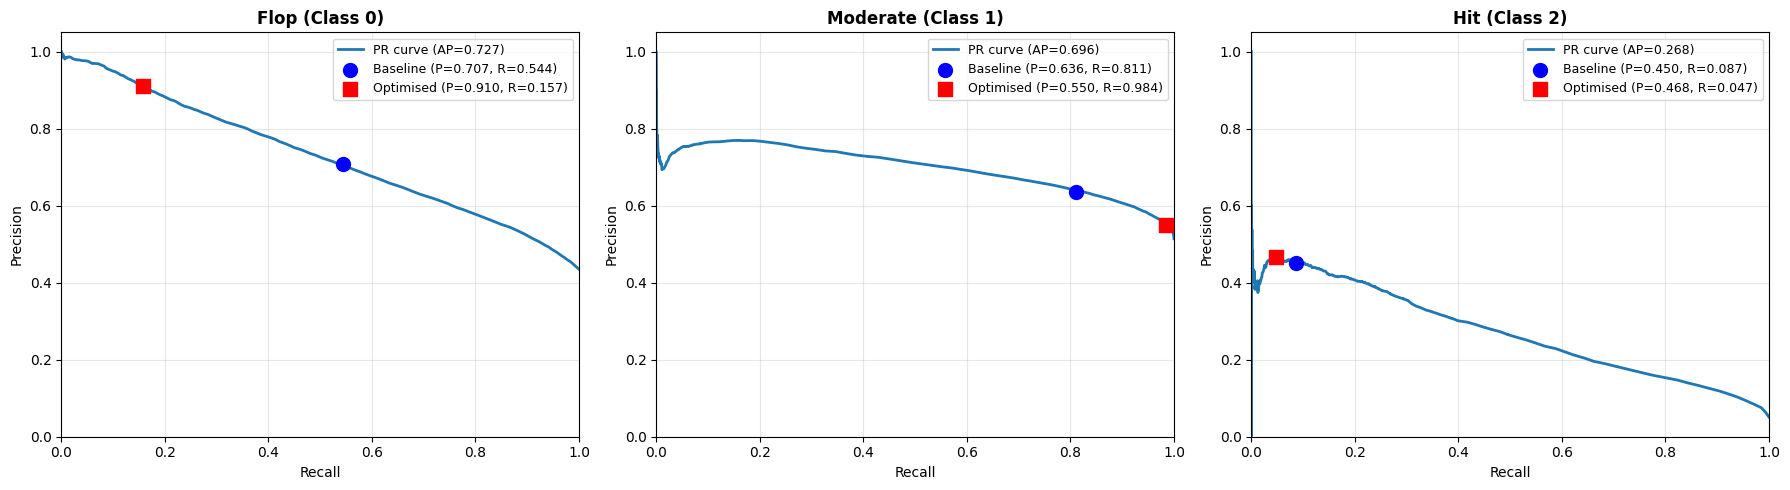


PRECISION-RECALL SUMMARY

Flop (Class 0):
  AP: 0.7268
  Baseline  — P: 0.7073, R: 0.5443
  Optimised — P: 0.9101, R: 0.1571  (ΔP: +0.2028, ΔR: -0.3872)

Moderate (Class 1):
  AP: 0.6961
  Baseline  — P: 0.6360, R: 0.8107
  Optimised — P: 0.5502, R: 0.9844  (ΔP: -0.0857, ΔR: +0.1737)

Hit (Class 2):
  AP: 0.2684
  Baseline  — P: 0.4499, R: 0.0867
  Optimised — P: 0.4677, R: 0.0471  (ΔP: +0.0178, ΔR: -0.0396)


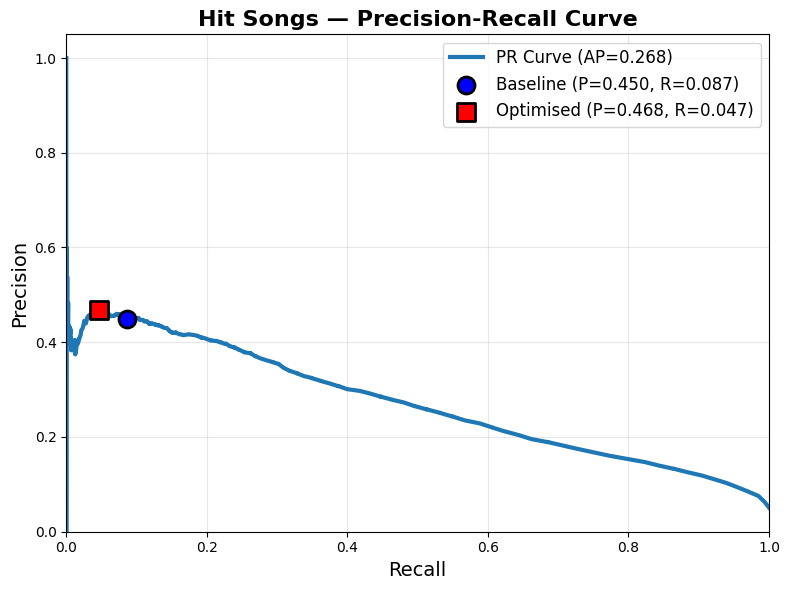

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ── Baseline & optimised predictions ──────────────────────────
y_pred_baseline = pipe_3class.predict(X_test)
probs_baseline = pipe_3class.predict_proba(X_test)

# Re-apply thresholding for the optimised variant
y_pred_optimized = []
for prob_row in probs_baseline:
    if prob_row[2] >= 0.50:
        y_pred_optimized.append(2)
    elif prob_row[0] >= 0.75:
        y_pred_optimized.append(0)
    elif prob_row[1] >= 0.50:
        y_pred_optimized.append(1)
    else:
        y_pred_optimized.append(1)
y_pred_optimized = np.array(y_pred_optimized)

# ── Per-class PR curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(class_names):
    ax = axes[idx]
    y_bin = (y_test == idx).astype(int)
    probs_cls = probs_baseline[:, idx]
    prec, rec, _ = precision_recall_curve(y_bin, probs_cls)
    ap = average_precision_score(y_bin, probs_cls)

    ax.plot(rec, prec, lw=2, label=f'PR curve (AP={ap:.3f})')

    # Baseline operating point
    bp = (y_pred_baseline == idx)[y_test == idx].sum() / max((y_pred_baseline == idx).sum(), 1)
    br = (y_pred_baseline == idx)[y_test == idx].sum() / max((y_test == idx).sum(), 1)
    ax.scatter(br, bp, s=100, c='blue', marker='o',
               label=f'Baseline (P={bp:.3f}, R={br:.3f})', zorder=5)

    # Optimised operating point
    op = (y_pred_optimized == idx)[y_test == idx].sum() / max((y_pred_optimized == idx).sum(), 1)
    orr = (y_pred_optimized == idx)[y_test == idx].sum() / max((y_test == idx).sum(), 1)
    ax.scatter(orr, op, s=100, c='red', marker='s',
               label=f'Optimised (P={op:.3f}, R={orr:.3f})', zorder=5)

    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{name} (Class {idx})', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────
print("\n" + "="*60)
print("PRECISION-RECALL SUMMARY")
print("="*60)
for idx, name in enumerate(class_names):
    y_bin = (y_test == idx).astype(int)
    ap = average_precision_score(y_bin, probs_baseline[:, idx])
    bp = (y_pred_baseline == idx)[y_test == idx].sum() / max((y_pred_baseline == idx).sum(), 1)
    br = (y_pred_baseline == idx)[y_test == idx].sum() / max((y_test == idx).sum(), 1)
    op = (y_pred_optimized == idx)[y_test == idx].sum() / max((y_pred_optimized == idx).sum(), 1)
    orr = (y_pred_optimized == idx)[y_test == idx].sum() / max((y_test == idx).sum(), 1)
    print(f"\n{name} (Class {idx}):")
    print(f"  AP: {ap:.4f}")
    print(f"  Baseline  — P: {bp:.4f}, R: {br:.4f}")
    print(f"  Optimised — P: {op:.4f}, R: {orr:.4f}  (ΔP: {op-bp:+.4f}, ΔR: {orr-br:+.4f})")

# ── Dedicated Hit-class PR plot ───────────────────────────────
plt.figure(figsize=(8, 6))
y_hit = (y_test == 2).astype(int)
p_h = probs_baseline[:, 2]
prec_h, rec_h, _ = precision_recall_curve(y_hit, p_h)
ap_h = average_precision_score(y_hit, p_h)

plt.plot(rec_h, prec_h, lw=3, label=f'PR Curve (AP={ap_h:.3f})')

bp_h = (y_pred_baseline == 2)[y_test == 2].sum() / max((y_pred_baseline == 2).sum(), 1)
br_h = (y_pred_baseline == 2)[y_test == 2].sum() / max((y_test == 2).sum(), 1)
plt.scatter(br_h, bp_h, s=150, c='blue', marker='o', edgecolors='black', lw=2,
            label=f'Baseline (P={bp_h:.3f}, R={br_h:.3f})', zorder=5)

op_h = (y_pred_optimized == 2)[y_test == 2].sum() / max((y_pred_optimized == 2).sum(), 1)
or_h = (y_pred_optimized == 2)[y_test == 2].sum() / max((y_test == 2).sum(), 1)
plt.scatter(or_h, op_h, s=150, c='red', marker='s', edgecolors='black', lw=2,
            label=f'Optimised (P={op_h:.3f}, R={or_h:.3f})', zorder=5)

plt.xlabel('Recall', fontsize=14); plt.ylabel('Precision', fontsize=14)
plt.title('Hit Songs — Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.legend(fontsize=12); plt.grid(alpha=0.3)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout()
plt.savefig('hit_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Part 3 — Failure Mode Analysis (GHW5)

## Failure Mode Analysis
Deep-dive into where the 3-class model breaks: false positives, false negatives,
cost implications ($50 K per mis-promoted song), and performance bias across
feature segments (energy, danceability, artist popularity).

> **Note:** This section reuses `pipe_3class`, `X_test`, `y_test`, `y_pred_thresh`,
> and `importance_df` from Part 2 — no data is reloaded.

FAILURE MODE ANALYSIS — WHERE DOES THE MODEL BREAK?

Total predictions: 102,788
  Flop:     34,212 (33.3%)
  Moderate: 67,569 (65.7%)
  Hit:      1,007 (1.0%)

Actual — Flops: 44,719  Moderate: 52,846  Hits: 5,223

HIT FALSE POSITIVES (Wasted Marketing $)
Predicted as Hit: 1,007
  True Positives:  453
  False Positives: 554

Cost: 554 × $50K = $27,700,000
  Actually Flop: 232 (41.9%)
  Actually Moderate: 322 (58.1%)

Feature patterns — Hit FP vs Caught Hits:
  avg_artist_popularity: FP=76.464  TP=83.325  Δ=6.861
  lyric_word_count: FP=388.206  TP=448.459  Δ=60.253
  year: FP=2010.273  TP=2014.146  Δ=3.873
  liveness: FP=0.185  TP=0.178  Δ=0.007
  loudness: FP=-6.708  TP=-6.726  Δ=0.018

FLOP FALSE POSITIVES (Songs we wrongly dismissed)
Predicted as Flop: 34,212
  True Positives:  24,240
  False Positives: 9,972
  Actually Moderate: 9,582 (96.1%)
  Actually Hit: 390 (3.9%) ← Hits dismissed as Flops!

HIT FALSE NEGATIVES (Missed Opportunities)
Actual Hits: 5,223
  Caught:  453 (8.7%)
  M

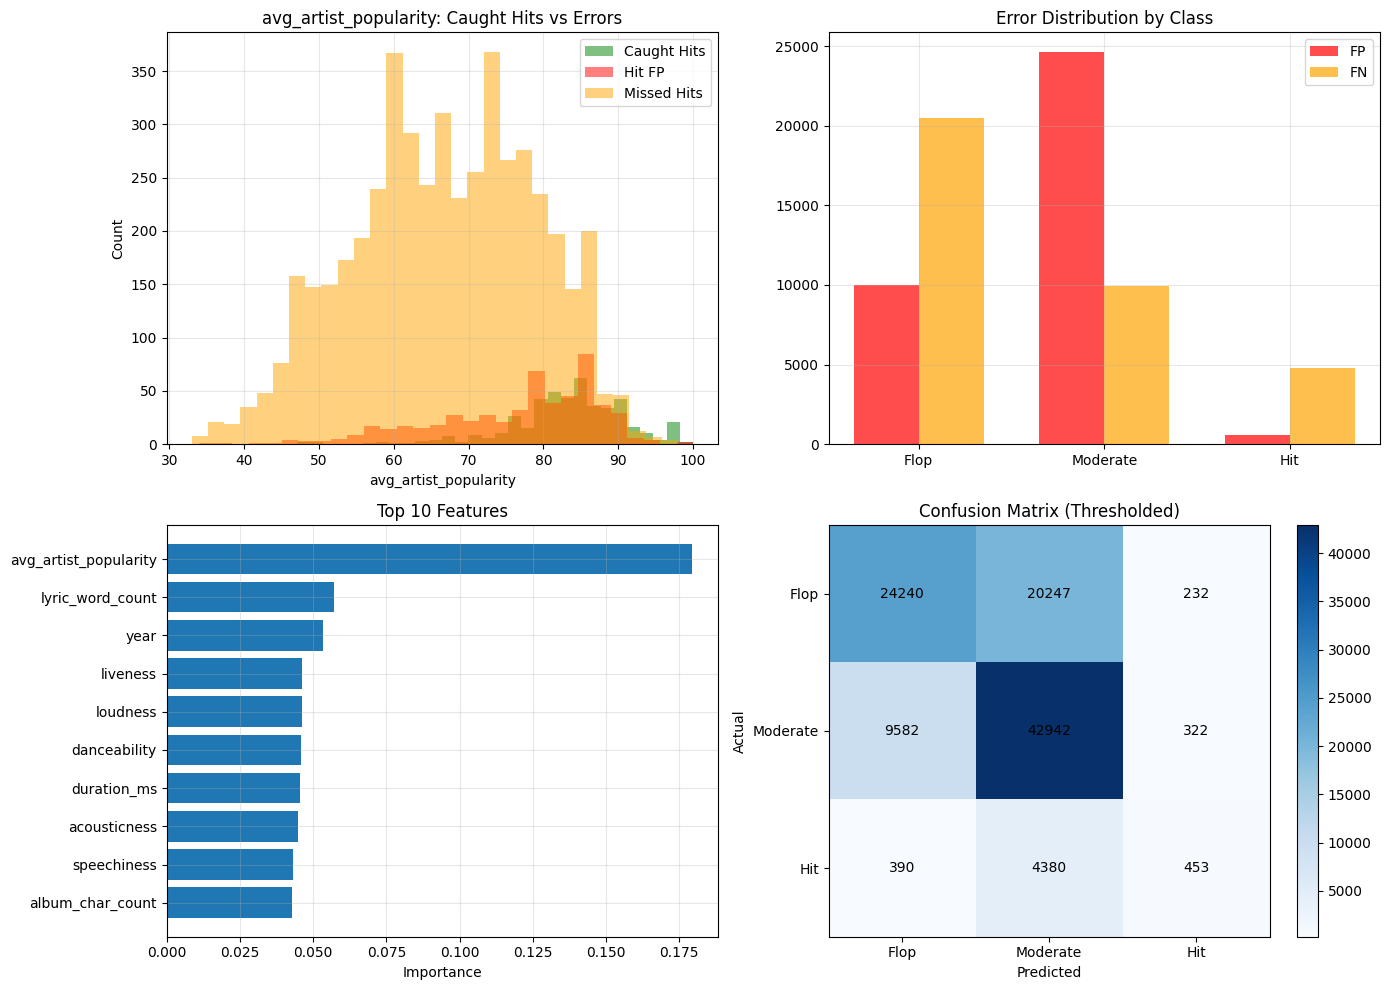


FAILURE MODE ANALYSIS COMPLETE


In [5]:
from sklearn.metrics import accuracy_score

print("="*70)
print("FAILURE MODE ANALYSIS — WHERE DOES THE MODEL BREAK?")
print("="*70)

# ═══════════════════════════════════════════════════════════════
# A. Prediction Summary
# ═══════════════════════════════════════════════════════════════
total = len(y_pred_thresh)
flop_pred  = (y_pred_thresh == 0).sum()
mod_pred   = (y_pred_thresh == 1).sum()
hit_pred   = (y_pred_thresh == 2).sum()

print(f"\nTotal predictions: {total:,}")
print(f"  Flop:     {flop_pred:,} ({flop_pred/total*100:.1f}%)")
print(f"  Moderate: {mod_pred:,} ({mod_pred/total*100:.1f}%)")
print(f"  Hit:      {hit_pred:,} ({hit_pred/total*100:.1f}%)")

actual_flops = (y_test == 0).sum()
actual_mod   = (y_test == 1).sum()
actual_hits  = (y_test == 2).sum()
print(f"\nActual — Flops: {actual_flops:,}  Moderate: {actual_mod:,}  Hits: {actual_hits:,}")

# ═══════════════════════════════════════════════════════════════
# B. Hit False Positives (most costly errors)
# ═══════════════════════════════════════════════════════════════
hit_fp_mask     = (y_pred_thresh == 2) & (y_test != 2)
caught_hit_mask = (y_pred_thresh == 2) & (y_test == 2)
hit_fp_features = X_test[hit_fp_mask]
caught_hits     = X_test[caught_hit_mask]

print("\n" + "="*60)
print("HIT FALSE POSITIVES (Wasted Marketing $)")
print("="*60)
print(f"Predicted as Hit: {hit_pred:,}")
print(f"  True Positives:  {caught_hit_mask.sum():,}")
print(f"  False Positives: {hit_fp_mask.sum():,}")
print(f"\nCost: {hit_fp_mask.sum():,} × $50K = ${hit_fp_mask.sum() * 50_000:,}")

hit_fp_labels = y_test[hit_fp_mask]
for i in range(2):
    c = (hit_fp_labels == i).sum()
    pct = c / len(hit_fp_labels) * 100 if len(hit_fp_labels) else 0
    print(f"  Actually {'Flop' if i==0 else 'Moderate'}: {c:,} ({pct:.1f}%)")

# Feature comparison: false positives vs caught hits
key_features = importance_df.head(5)['feature'].tolist()
print("\nFeature patterns — Hit FP vs Caught Hits:")
for feat in key_features:
    if feat in X_test.columns:
        fp_m = hit_fp_features[feat].mean() if len(hit_fp_features) else 0
        tp_m = caught_hits[feat].mean() if len(caught_hits) else 0
        print(f"  {feat}: FP={fp_m:.3f}  TP={tp_m:.3f}  Δ={abs(fp_m-tp_m):.3f}")

# ═══════════════════════════════════════════════════════════════
# C. Flop False Positives
# ═══════════════════════════════════════════════════════════════
flop_fp_mask = (y_pred_thresh == 0) & (y_test != 0)
correct_flop = (y_pred_thresh == 0) & (y_test == 0)

print("\n" + "="*60)
print("FLOP FALSE POSITIVES (Songs we wrongly dismissed)")
print("="*60)
print(f"Predicted as Flop: {flop_pred:,}")
print(f"  True Positives:  {correct_flop.sum():,}")
print(f"  False Positives: {flop_fp_mask.sum():,}")

flop_fp_labels = y_test[flop_fp_mask]
for i in [1, 2]:
    c = (flop_fp_labels == i).sum()
    pct = c / len(flop_fp_labels) * 100 if len(flop_fp_labels) else 0
    tag = " ← Hits dismissed as Flops!" if i == 2 else ""
    print(f"  Actually {class_names[i]}: {c:,} ({pct:.1f}%){tag}")

# ═══════════════════════════════════════════════════════════════
# D. Hit False Negatives (Missed Opportunities)
# ═══════════════════════════════════════════════════════════════
hit_fn_mask = (y_pred_thresh != 2) & (y_test == 2)
hit_fn_features = X_test[hit_fn_mask]
hit_fn_preds = y_pred_thresh[hit_fn_mask]

print("\n" + "="*60)
print("HIT FALSE NEGATIVES (Missed Opportunities)")
print("="*60)
print(f"Actual Hits: {actual_hits:,}")
print(f"  Caught:  {caught_hit_mask.sum():,} ({caught_hit_mask.sum()/actual_hits*100:.1f}%)")
print(f"  Missed:  {hit_fn_mask.sum():,} ({hit_fn_mask.sum()/actual_hits*100:.1f}%)")

for i in range(2):
    c = (hit_fn_preds == i).sum()
    pct = c / len(hit_fn_preds) * 100 if len(hit_fn_preds) else 0
    print(f"  Predicted as {class_names[i]}: {c:,} ({pct:.1f}%)")

print("\nFeature patterns — Missed Hits vs Caught Hits:")
for feat in key_features:
    if feat in X_test.columns:
        fn_m = hit_fn_features[feat].mean() if len(hit_fn_features) else 0
        tp_m = caught_hits[feat].mean() if len(caught_hits) else 0
        print(f"  {feat}: Missed={fn_m:.3f}  Caught={tp_m:.3f}  Δ={abs(fn_m-tp_m):.3f}")

# ═══════════════════════════════════════════════════════════════
# E. Cost Summary
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("COST SUMMARY")
print("="*60)
print(f"Hit False Positives: {hit_fp_mask.sum():,} × $50K = ${hit_fp_mask.sum()*50_000:,}")
print("This represents wasted marketing spend on songs that won't become hits.")

# ═══════════════════════════════════════════════════════════════
# F. Bias Check — Performance by Segment
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("BIAS CHECK — PERFORMANCE ACROSS SEGMENTS")
print("="*60)

X_seg = X_test.copy()
X_seg['y_true'] = y_test
X_seg['y_pred'] = y_pred_thresh

def segment_report(col, bins, labels):
    if col not in X_seg.columns:
        print(f"\n'{col}' not in features — skipped.")
        return
    X_seg['_seg'] = pd.cut(X_seg[col], bins=bins, labels=labels)
    print(f"\n--- By {col} ---")
    for lab in labels:
        mask = X_seg['_seg'] == lab
        if mask.sum() == 0:
            continue
        acc = accuracy_score(X_seg.loc[mask, 'y_true'], X_seg.loc[mask, 'y_pred'])
        hit_m = X_seg.loc[mask, 'y_pred'] == 2
        hit_p = (X_seg.loc[mask, 'y_pred'][hit_m] == X_seg.loc[mask, 'y_true'][hit_m]).sum() / max(hit_m.sum(), 1)
        print(f"  {lab}: n={mask.sum():,}  Acc={acc:.3f}  Hit Prec={hit_p:.3f}")
    X_seg.drop(columns='_seg', inplace=True)

segment_report('energy', [0, 0.4, 0.7, 1.0], ['Low', 'Medium', 'High'])
segment_report('danceability', [0, 0.4, 0.7, 1.0], ['Low', 'Medium', 'High'])
segment_report('avg_artist_popularity', [0, 40, 60, 80, 100],
               ['Low (0-40)', 'Med (40-60)', 'High (60-80)', 'VHigh (80-100)'])

# ═══════════════════════════════════════════════════════════════
# G. Visualise Error Patterns (4-panel figure)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1 — Top feature distribution: caught hits vs errors
ax = axes[0, 0]
if key_features and key_features[0] in X_test.columns:
    feat = key_features[0]
    if len(caught_hits):
        ax.hist(caught_hits[feat], bins=30, alpha=0.5, label='Caught Hits', color='green')
    if hit_fp_mask.sum():
        ax.hist(hit_fp_features[feat], bins=30, alpha=0.5, label='Hit FP', color='red')
    if hit_fn_mask.sum():
        ax.hist(hit_fn_features[feat], bins=30, alpha=0.5, label='Missed Hits', color='orange')
    ax.set_xlabel(feat); ax.set_ylabel('Count')
    ax.set_title(f'{feat}: Caught Hits vs Errors'); ax.legend(); ax.grid(alpha=0.3)

# Panel 2 — FP / FN counts per class
ax = axes[0, 1]
err = [[((y_pred_thresh == i) & (y_test != i)).sum(),
        ((y_pred_thresh != i) & (y_test == i)).sum()] for i in range(3)]
x = np.arange(3); w = 0.35
ax.bar(x - w/2, [e[0] for e in err], w, label='FP', color='red', alpha=0.7)
ax.bar(x + w/2, [e[1] for e in err], w, label='FN', color='orange', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_title('Error Distribution by Class'); ax.legend(); ax.grid(alpha=0.3)

# Panel 3 — Top-10 feature importance
ax = axes[1, 0]
top10 = importance_df.head(10)
ax.barh(range(10), top10['importance'].values)
ax.set_yticks(range(10)); ax.set_yticklabels(top10['feature'].values)
ax.set_xlabel('Importance'); ax.set_title('Top 10 Features'); ax.invert_yaxis(); ax.grid(alpha=0.3)

# Panel 4 — Confusion matrix heatmap (thresholded)
ax = axes[1, 1]
cm_t = confusion_matrix(y_test, y_pred_thresh)
im = ax.imshow(cm_t, cmap='Blues', aspect='auto')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Thresholded)')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_t[i, j], ha='center', va='center')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('failure_mode_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("FAILURE MODE ANALYSIS COMPLETE")
print("="*60)